# 04 Oxygen evolution (IA-OER-001)

**Requirement:** `IA-OER-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

Oxygen evolution:

$$4\,\mathrm{OH^-} \to \mathrm{O_2} + 2\,\mathrm{H_2O} + 4\,\mathrm{e^-}$$

Layouts: planar, submerged, interdigitated trunk-and-projection, corrugated,
serpentine, discrete arrays, spiral bifilar, pleated
(EP Claims 1, 3, 12, 32, 38, 70, 77). Default porous metal mesh + OER catalyst (Claim 11).
OER sits closer to iron than ORR on charge and is electrically isolatable (US FIGS. 5A-5B).
Overpotential in $\mathrm{V}$; gas inventories in $\mathrm{mol}$.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.oer import OxygenEvolution, OER_LAYOUTS, LAYOUT_AREA_FACTOR
from plant_sim.components.base import integrate_component

print(OER_LAYOUTS)
oer = OxygenEvolution(P, layout="interdigitated")
t, y = integrate_component(
    lambda t, y: oer.rhs(
        t,
        y,
        {
            "I_oer_A": 20 * P.I_discharge_100h_A,
            "T_K": P.T_ep_sim_K,
            "a_oh": 6.0,
            "a_h2o": 0.72,
            "p_O2_Pa": P.P_atm_Pa,
            "oer_isolated": 0.0,
        },
        {},
    ),
    oer.y0(),
    (0, 800),
    n_eval=120,
)

('planar', 'submerged', 'interdigitated', 'corrugated', 'serpentine', 'discrete_array', 'spiral_bifilar', 'pleated')


## OER catalyst current and evolved oxygen

### What this plot illustrates

Charge-mode oxygen evolution on the dedicated OER electrode (dual-electrode architecture, EP [0049]; US Claim 16).

### Governing equations

$$4\,\mathrm{OH^-} \to \mathrm{O_2} + 2\,\mathrm{H_2O} + 4\,\mathrm{e^-}$$

$\dot n_{\mathrm{O_2}} = I_\mathrm{OER}/(4F)$.


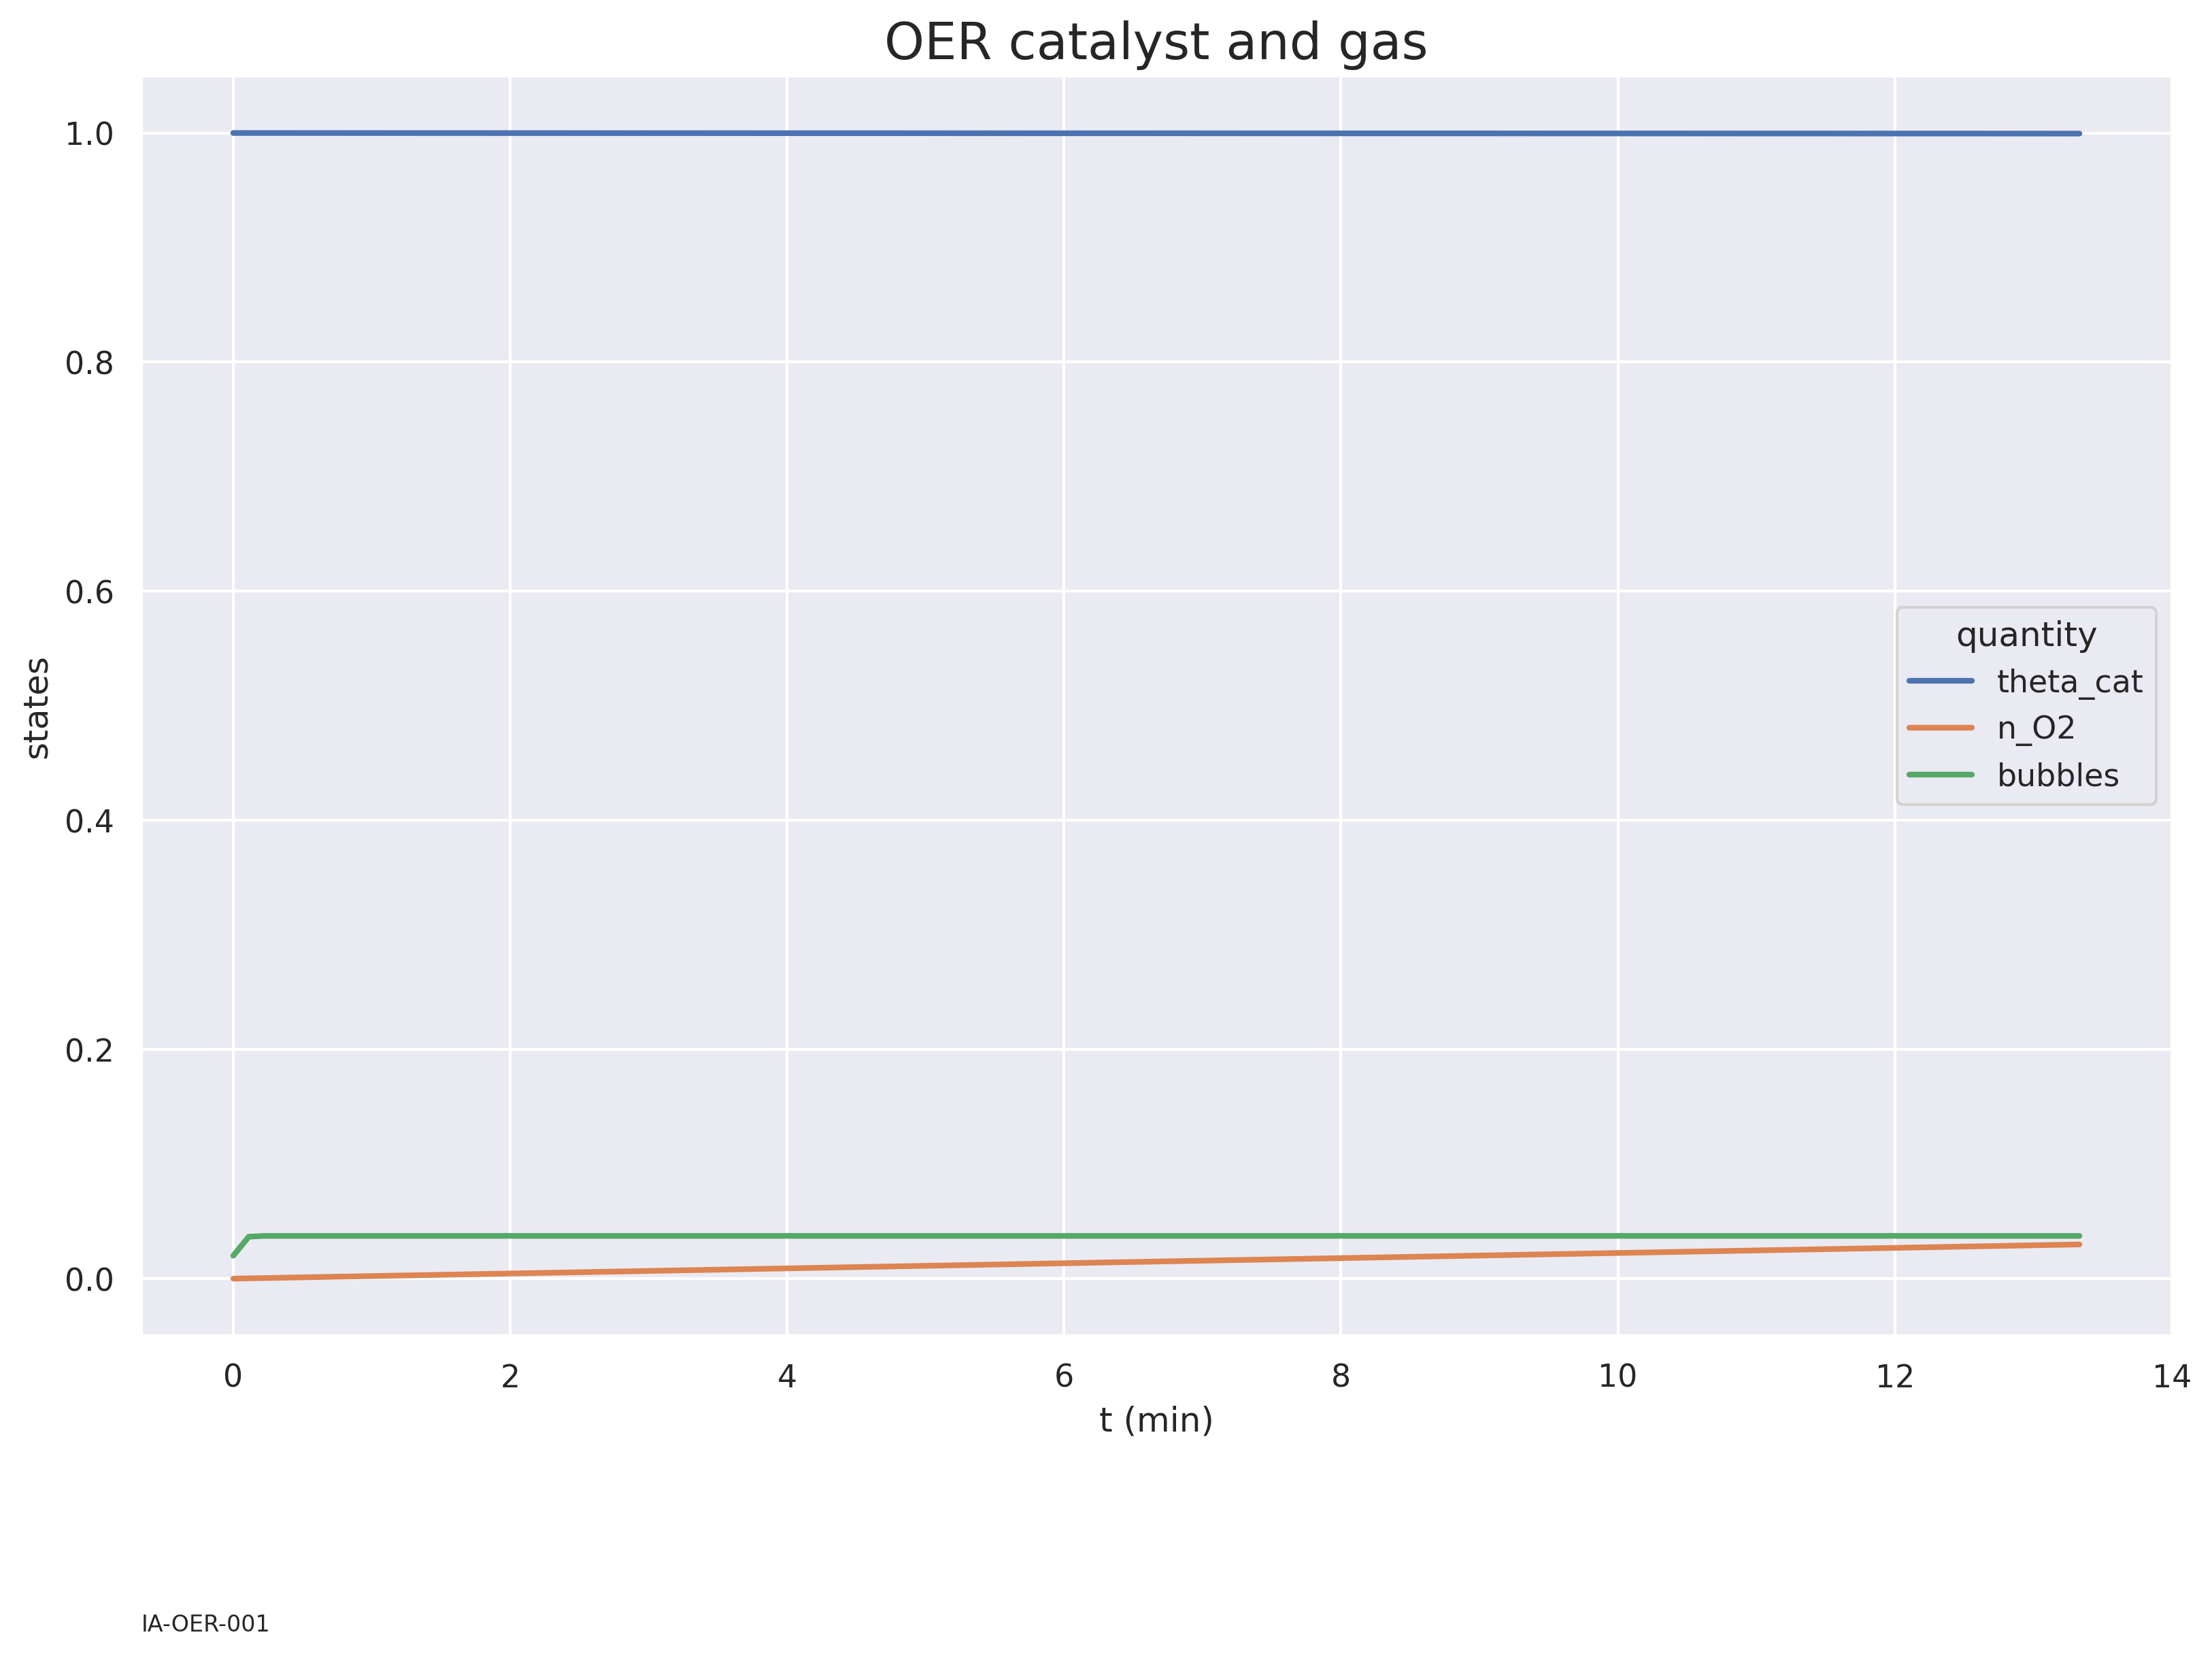

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 60),
        "theta_cat": (y[0]),
        "n_O2": (y[1]),
        "bubbles": (y[2]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (min)")
ax.set_ylabel("states")
ax.set_title("OER catalyst and gas")
ax.text(0.0, -0.22, "IA-OER-001", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## OER occupancy by electrode layout

### What this plot illustrates

Compares interdigitated, spiral bifilar, and pleated layouts for OER area occupancy (EP4602674A1 independent claims 1/20/38/55).

### Governing equations

Occupancy target from patent claims: OER geometric fraction $>25\%$ of the facing electrode area when the layout is configured for charge.


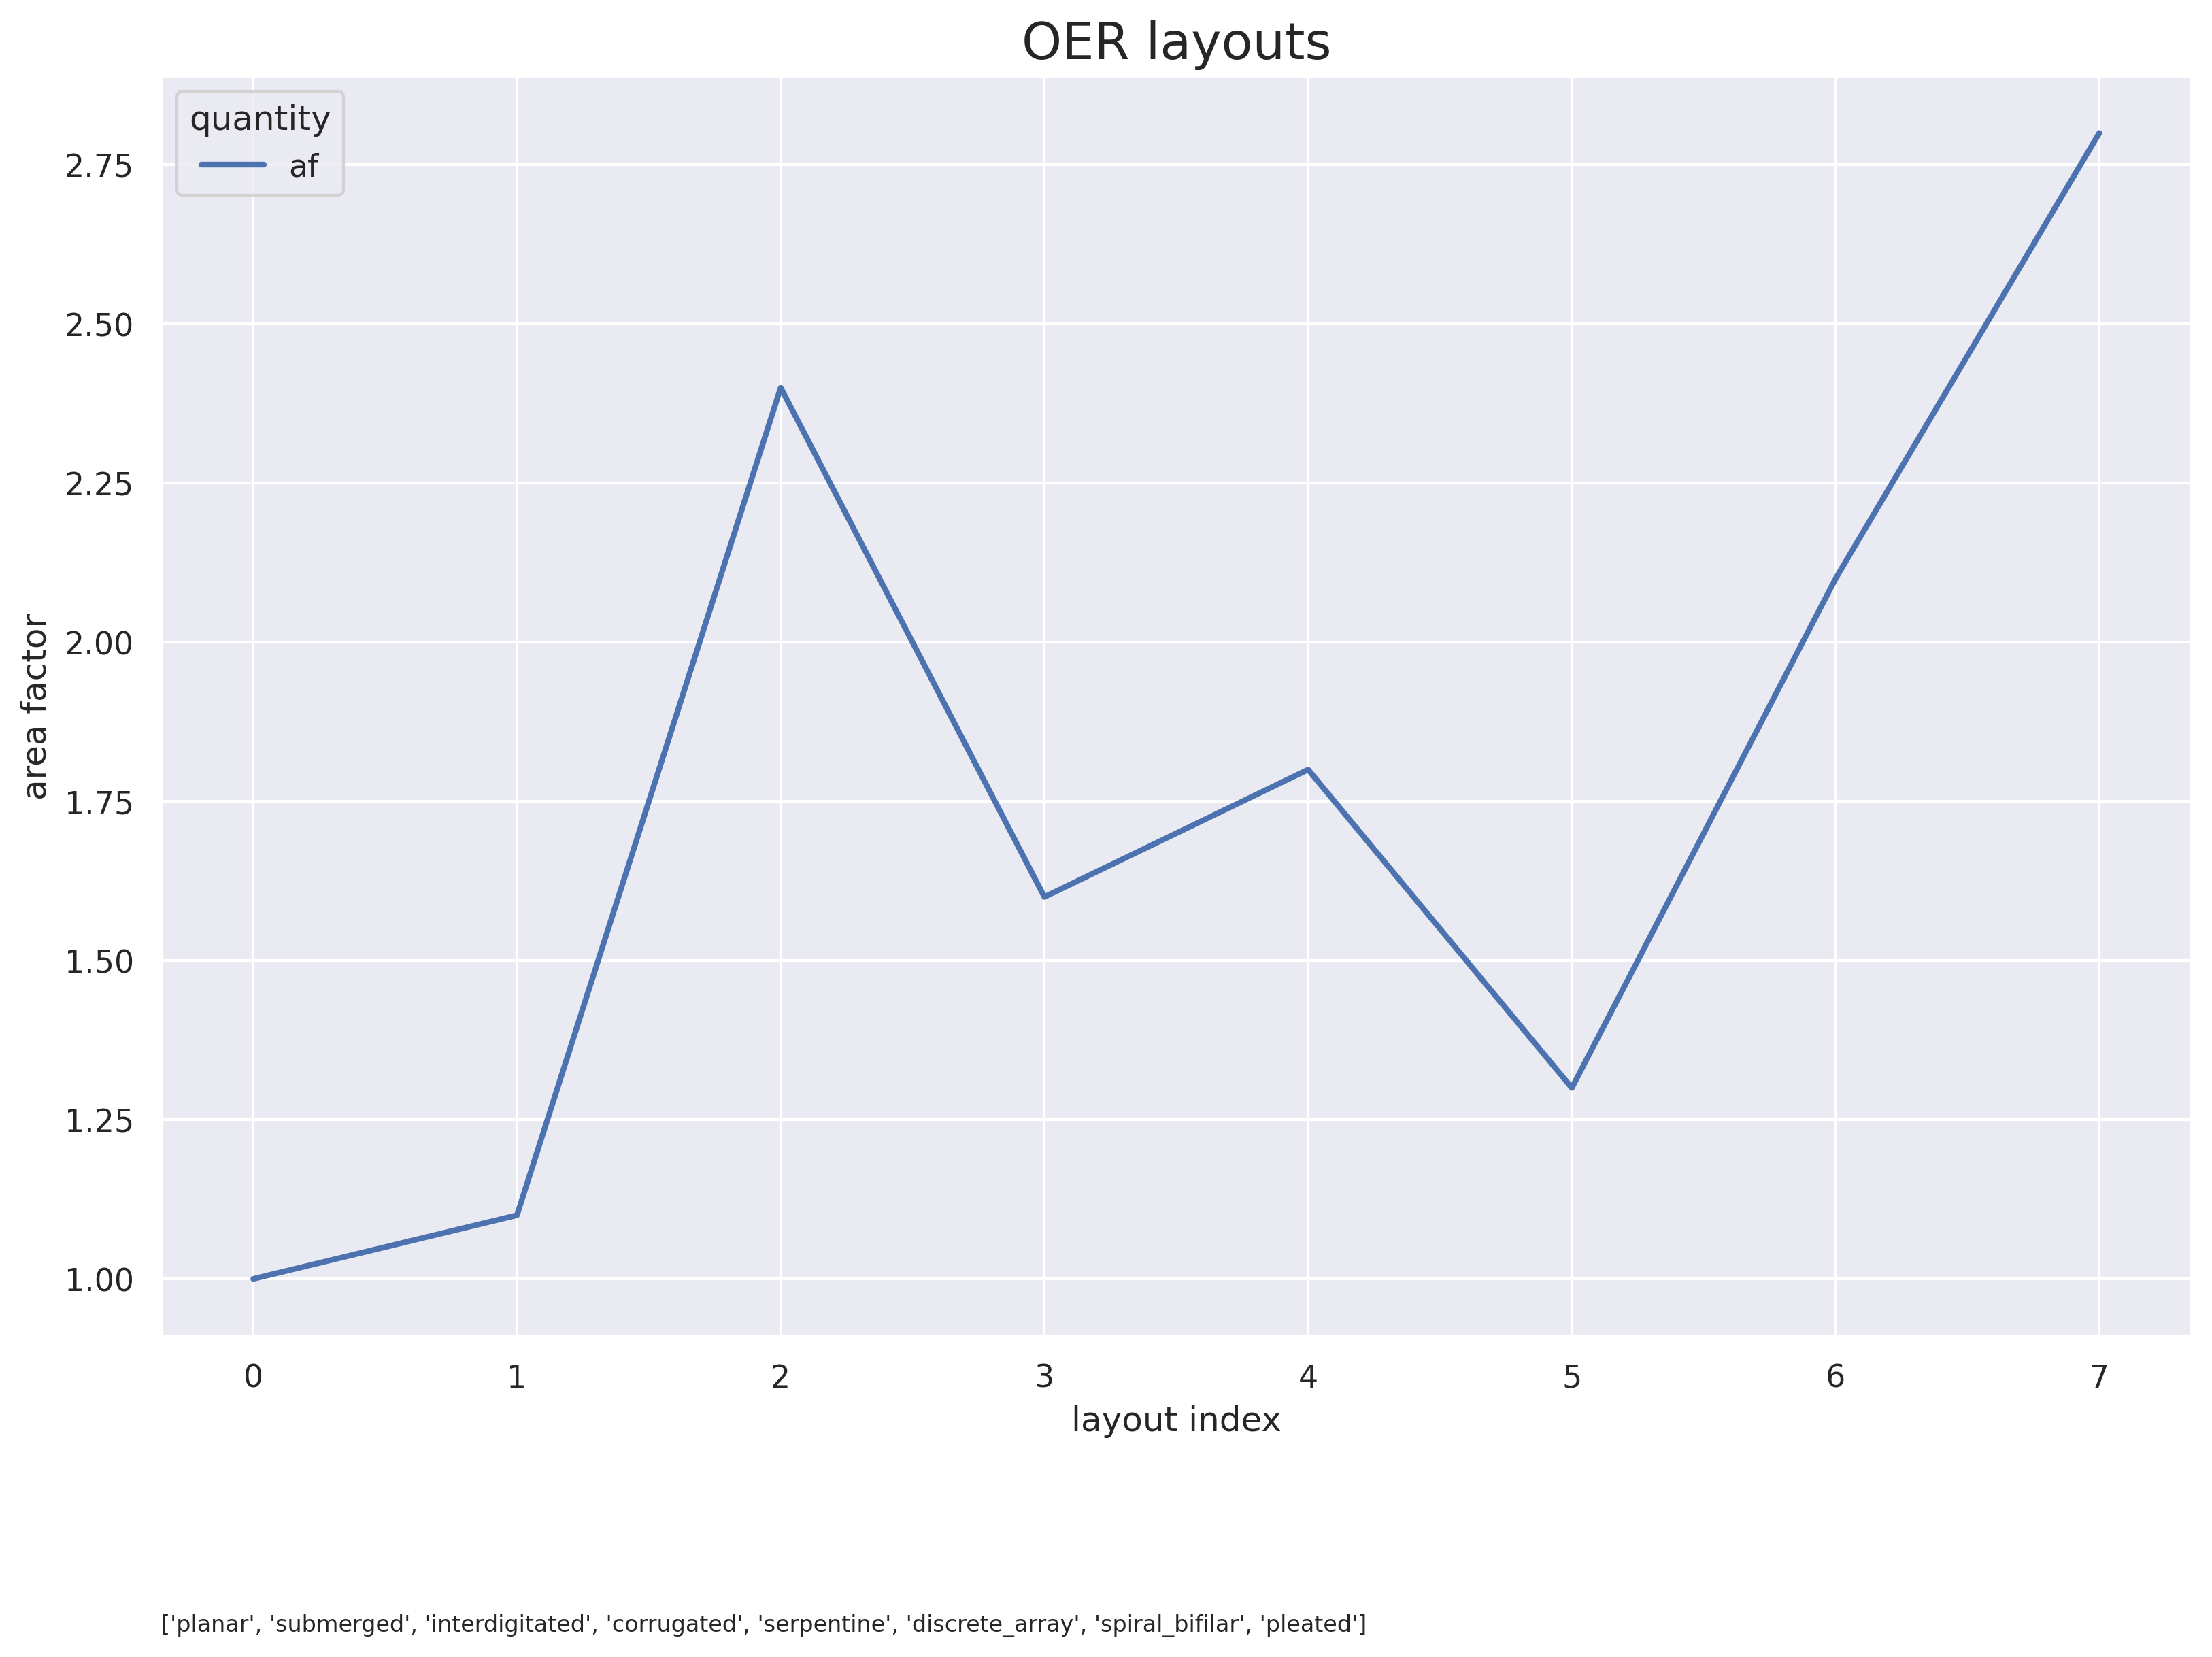

In [5]:
plot_frame = pd.DataFrame(
    {
        "x": (np.arange(len(LAYOUT_AREA_FACTOR))),
        "af": (np.array(list(LAYOUT_AREA_FACTOR.values()))),
    }
)
plot_long = plot_frame.melt(id_vars="x", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="x", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("layout index")
ax.set_ylabel("area factor")
ax.set_title("OER layouts")
ax.text(0.0, -0.22, str(list(LAYOUT_AREA_FACTOR)), transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Verification against patents / SSS002

In [6]:
print("Interdigitated shortens ionic path vs planar (EP [0050], FIGS. 19-21).")

Interdigitated shortens ionic path vs planar (EP [0050], FIGS. 19-21).
